# TNG300-1: particle-defined proto-halo / Lagrangian regions

This notebook directly tests whether the previously inferred optimal $z\simeq8$ environment scale traces the actual Lagrangian region of each snapshot-99 descendant. It loads the descendant FoF's dark-matter ParticleIDs at $z=0$, finds those same particles at snapshot 8, and measures the resulting proto-halo's size and shape.

The existing descendant and environment catalogs are reused; SubLink tracking is not repeated. The default workload is a reproducible, unique-descendant subsample of 20 halos per descendant-mass bin and at most $10^5$ equal-mass DM particles per halo. Both limits are parameters that can be increased after validating runtime and memory use.

## 1. Imports and TNG paths

In [1]:
from pathlib import Path
import warnings

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.stats import spearmanr
from tqdm.auto import tqdm
from IPython.display import display, Markdown

import illustris_python as il

plt.rcParams.update({
    "figure.figsize": (7.4, 5.0),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.size": 11,
})

base_candidates = [
    Path("/home/tnguser/sims.TNG/L205n2500TNG/output"),
    Path("../sims.TNG/TNG300-1/output").resolve(),
    Path("../sims.TNG/L205n2500TNG/output").resolve(),
]
basePath = next((p for p in base_candidates if p.is_dir()), None)
if basePath is None:
    raise FileNotFoundError("Set basePath to the TNG300-1 output directory.")

environment_catalog_path = Path.cwd() / "tng300_z8_M11_descendants_environment.csv"
descendant_catalog_path = Path.cwd() / "tng300_z8_M11_descendants.csv"
lagrangian_scale_path = Path.cwd() / "tng300_environment_lagrangian_summary.csv"
robustness_summary_path = Path.cwd() / "tng300_environment_robustness_summary.csv"

cache_dir = Path.cwd() / "protohalo_particle_cache"
id_cache_dir = cache_dir / "z0_sampled_dm_ids"
coord_cache_dir = cache_dir / "z8_matched_dm_coordinates"
cache_dir.mkdir(exist_ok=True)
id_cache_dir.mkdir(exist_ok=True)
coord_cache_dir.mkdir(exist_ok=True)

snap_z8, snap_z0 = 8, 99
random_seed = 314159
test_mode = False  # True: 2 halos/bin and 10,000 DM particles/halo for an I/O smoke test
n_per_mass_bin = 2 if test_mode else 20
max_dm_particles_per_halo = 10_000 #if test_mode else 100_000
particle_id_block_size = 2_000_000  # limits temporary memory during snapshot matching
min_match_fraction = 0.98
restrict_z0_particles_to_r200c = True
fprog_radii_cMpc = np.array([2, 3, 5, 8, 10, 15, 20], dtype=float)
max_plot_particles = 30_000

print(f"basePath: {basePath}")
print(f"cache directory: {cache_dir}")
print(f"test_mode={test_mode}; halos/bin={n_per_mass_bin}; max DM particles/halo={max_dm_particles_per_halo:,}")

basePath: /home/tnguser/sims.TNG/L205n2500TNG/output
cache directory: /home/tnguser/tng-work/protohalo_particle_cache
test_mode=False; halos/bin=20; max DM particles/halo=10,000


## 2. Cosmology and units

Snapshot coordinates are comoving kpc/$h$ and are converted to cMpc by division by $1000h$. The analytic radius uses physical $M_0$ in $M_\odot$ and $\bar\rho_{m,0}$ in $M_\odot\,\mathrm{Mpc}^{-3}$, producing a comoving Mpc radius directly comparable to the particle coordinates.

In [2]:
header_z8 = il.groupcat.loadHeader(str(basePath), snap_z8)
h = float(header_z8["HubbleParam"])
Omega_m = float(header_z8["Omega0"])
z_z8 = float(header_z8["Redshift"])
box_size_cMpc = float(header_z8["BoxSize"]) / (1000.0*h)
rho_crit0_msun_mpc3 = 2.77536627e11 * h**2
rho_m0_msun_mpc3 = Omega_m * rho_crit0_msun_mpc3

assert np.isclose(h, 0.6774, atol=1e-4, rtol=0)
print(f"z={z_z8:.6f}, h={h:.4f}, Omega_m={Omega_m:.4f}")
print(f"box size={box_size_cMpc:.3f} cMpc")
print(f"rho_m,0={rho_m0_msun_mpc3:.5e} Msun/Mpc^3")

z=8.012173, h=0.6774, Omega_m=0.3089
box size=302.628 cMpc
rho_m,0=3.93395e+10 Msun/Mpc^3


## 3. Load target, descendant, and environment catalogs

The environment catalog is preferred because it already contains `Nhalo_R10` and `Ngal_R10`. If it is absent, the smaller descendant catalog is accepted, but the direct environment-comparison section will be unavailable.

In [3]:
catalog_path = environment_catalog_path if environment_catalog_path.is_file() else descendant_catalog_path
if not catalog_path.is_file():
    raise FileNotFoundError("Run the descendant analysis first.")

targets_all = pd.read_csv(catalog_path)
required = [
    "GroupID_z8", "SubhaloID_z8", "M200c_z8", "logM200c_z8",
    "GroupID_z0", "SubhaloID_z0", "M200c_z0", "logM200c_z0",
]
missing = sorted(set(required) - set(targets_all.columns))
if missing:
    raise ValueError(f"Missing required columns: {missing}")

targets_all = targets_all.dropna(subset=required).copy()
targets_all = targets_all[
    (targets_all["logM200c_z8"] > 10.8) & (targets_all["logM200c_z8"] < 11.2)
].copy()
for column in ["GroupID_z8", "SubhaloID_z8", "GroupID_z0", "SubhaloID_z0"]:
    targets_all[column] = targets_all[column].astype(np.int64)

group_pos_z8 = il.groupcat.loadHalos(str(basePath), snap_z8, fields=["GroupPos"])
group_pos_z8_cMpc = np.mod(np.asarray(group_pos_z8, float)/(1000.0*h), box_size_cMpc)

print(f"Loaded {len(targets_all):,} tracked z≈8 targets from {catalog_path.name}")
print(f"Unique snapshot-99 FoF descendants: {targets_all['GroupID_z0'].nunique():,}")
print(f"Nhalo_R10 available: {'Nhalo_R10' in targets_all.columns}")

Loaded 3,099 tracked z≈8 targets from tng300_z8_M11_descendants_environment.csv
Unique snapshot-99 FoF descendants: 1,761
Nhalo_R10 available: True


## 4. Select a reproducible representative subsample

Multiple $z\simeq8$ targets can share one snapshot-99 FoF descendant. Particle-defined Lagrangian regions are therefore sampled at the **unique descendant** level. For each descendant, the most massive selected $z\simeq8$ progenitor is retained, then up to 20 descendants are drawn from each requested mass bin with a fixed seed.

In [4]:
unique_desc = (
    targets_all.sort_values("M200c_z8", ascending=False)
    .drop_duplicates("GroupID_z0", keep="first")
    .copy()
)
mass_edges = [12.5, 13.5, 14.0, 14.5, np.inf]
mass_labels = ["12.5-13.5", "13.5-14.0", "14.0-14.5", ">14.5"]
unique_desc["M0_bin"] = pd.cut(
    unique_desc["logM200c_z0"], mass_edges, labels=mass_labels, right=False
)

rng = np.random.default_rng(random_seed)
sample_parts = []
for label in mass_labels:
    candidates = unique_desc[unique_desc["M0_bin"] == label]
    n_take = min(n_per_mass_bin, len(candidates))
    chosen = rng.choice(candidates.index.to_numpy(), size=n_take, replace=False)
    sample_parts.append(candidates.loc[chosen])
sample = pd.concat(sample_parts).sort_values(["M0_bin", "logM200c_z0"]).reset_index(drop=True)

sample["R_Lag_analytic_cMpc"] = (
    3.0*sample["M200c_z0"]/(4.0*np.pi*rho_m0_msun_mpc3)
)**(1.0/3.0)
sample["TargetX_cMpc"] = group_pos_z8_cMpc[sample["GroupID_z8"].to_numpy(), 0]
sample["TargetY_cMpc"] = group_pos_z8_cMpc[sample["GroupID_z8"].to_numpy(), 1]
sample["TargetZ_cMpc"] = group_pos_z8_cMpc[sample["GroupID_z8"].to_numpy(), 2]

sample.to_csv(cache_dir/"selected_unique_descendants.csv", index=False)
display(sample.groupby("M0_bin", observed=True).agg(N=("GroupID_z0", "size"),
                                                     min_logM0=("logM200c_z0", "min"),
                                                     max_logM0=("logM200c_z0", "max")))
print(f"Selected {len(sample)} unique descendants.")

,N,min_logM0,max_logM0
M0_bin,,,
12.5-13.5,20,12.548933,13.452669
13.5-14.0,20,13.537056,13.988283
14.0-14.5,20,14.005859,14.445369
>14.5,20,14.521800,15.186332


Selected 80 unique descendants.


## 5. Load snapshot-99 descendant DM ParticleIDs

`snapshot.loadHalo(..., 'dm')` first returns the PartType1 particles in the full FoF group. By default, those particles are then restricted to the snapshot-99 `Group_R_Crit200` sphere, making the particle-defined region consistent with the $M_{200c}$ used for the analytic radius. Set `restrict_z0_particles_to_r200c=False` for a full-FoF membership sensitivity test. TNG300-1 DM particles have a single mass, so number weighting is mass weighting. To control memory and matching cost, halos with more than `max_dm_particles_per_halo` selected particles are deterministically subsampled by the smallest SplitMix64 hashes of their ParticleIDs.

In [5]:
def splitmix64(values, seed=0):
    x = np.asarray(values, dtype=np.uint64) + np.uint64(seed) + np.uint64(0x9E3779B97F4A7C15)
    x = (x ^ (x >> np.uint64(30))) * np.uint64(0xBF58476D1CE4E5B9)
    x = (x ^ (x >> np.uint64(27))) * np.uint64(0x94D049BB133111EB)
    return x ^ (x >> np.uint64(31))


def extract_particle_ids(load_result):
    if isinstance(load_result, dict):
        return np.asarray(load_result["ParticleIDs"], dtype=np.uint64)
    return np.asarray(load_result, dtype=np.uint64)


def deterministic_id_subsample(ids, maximum, seed):
    ids = np.asarray(ids, dtype=np.uint64)
    if len(ids) <= maximum:
        return ids.copy()
    hashes = splitmix64(ids, seed)
    keep = np.argpartition(hashes, maximum-1)[:maximum]
    return ids[keep]


def id_fingerprint(ids):
    ids = np.asarray(ids, dtype=np.uint64)
    return np.bitwise_xor.reduce(ids, initial=np.uint64(0))


id_manifest_rows = []
box_size_code_z0 = float(il.groupcat.loadHeader(str(basePath), snap_z0)["BoxSize"])
for row in tqdm(sample.itertuples(index=False), total=len(sample), desc="z=0 descendant DM IDs"):
    group_id = int(row.GroupID_z0)
    cache_path = id_cache_dir/f"group_{group_id}_dm_ids.npz"
    sampling_seed = random_seed + group_id
    cache_valid = False
    if cache_path.is_file():
        cached = np.load(cache_path)
        cache_valid = (
            "MaxSample" in cached.files and "SamplingSeed" in cached.files
            and "RestrictedToR200c" in cached.files
            and int(cached["MaxSample"]) == max_dm_particles_per_halo
            and int(cached["SamplingSeed"]) == sampling_seed
            and bool(cached["RestrictedToR200c"]) == restrict_z0_particles_to_r200c
        )
    if cache_valid:
        sampled_ids = cached["ParticleIDs"].astype(np.uint64)
        n_total = int(cached["N_total"])
    else:
        fields = ["ParticleIDs", "Coordinates"] if restrict_z0_particles_to_r200c else ["ParticleIDs"]
        loaded = il.snapshot.loadHalo(str(basePath), snap_z0, group_id, "dm", fields=fields)
        if restrict_z0_particles_to_r200c:
            all_ids = np.asarray(loaded["ParticleIDs"], dtype=np.uint64)
            coordinates = np.asarray(loaded["Coordinates"], dtype=float)
            halo = il.groupcat.loadSingle(str(basePath), snap_z0, haloID=group_id)
            center = np.asarray(halo["GroupPos"], dtype=float)
            radius = float(halo["Group_R_Crit200"])
            delta = (coordinates-center+box_size_code_z0/2.0) % box_size_code_z0 - box_size_code_z0/2.0
            inside = np.sqrt(np.sum(delta**2, axis=1)) < radius
            all_ids = all_ids[inside]
        else:
            all_ids = extract_particle_ids(loaded)
        n_total = len(all_ids)
        sampled_ids = deterministic_id_subsample(
            all_ids, max_dm_particles_per_halo, seed=sampling_seed
        )
        np.savez(
            cache_path, ParticleIDs=sampled_ids, N_total=n_total,
            MaxSample=max_dm_particles_per_halo, SamplingSeed=sampling_seed,
            IDFingerprint=id_fingerprint(sampled_ids),
            RestrictedToR200c=restrict_z0_particles_to_r200c,
        )
    id_manifest_rows.append({
        "GroupID_z0": group_id, "N_DM_total": n_total,
        "N_DM_sampled": len(sampled_ids), "sampling_fraction": len(sampled_ids)/n_total,
        "ParticleMembership": "R200c" if restrict_z0_particles_to_r200c else "full FoF",
    })

id_manifest = pd.DataFrame(id_manifest_rows)
sample = sample.merge(id_manifest, on="GroupID_z0", how="left", validate="one_to_one")
id_manifest.to_csv(cache_dir/"z0_dm_id_manifest.csv", index=False)
display(id_manifest.describe())

z=0 descendant DM IDs:   0%|          | 0/80 [00:00<?, ?it/s]

,GroupID_z0,N_DM_total,N_DM_sampled,sampling_fraction
count,80.00000,8.000000e+01,80.0,80.000000
mean,1153.31250,2.968436e+06,10000.0,0.020153
std,2056.13722,3.867536e+06,0.0,0.032757
min,0.00000,5.713600e+04,10000.0,0.000457
25%,39.75000,4.923138e+05,10000.0,0.002456
50%,287.00000,1.449996e+06,10000.0,0.006898
75%,1213.00000,4.097920e+06,10000.0,0.020442
max,9728.00000,2.187019e+07,10000.0,0.175021


## 6. Match the sampled IDs in snapshot 8

The snapshot is scanned **once for all uncached halos**. The required ParticleIDs are indexed once with a pandas `UInt64Index` hash table. Each snapshot chunk is read in blocks, and hash lookup replaces the much slower operation of binary-searching every snapshot particle against the full target-ID array.

Matches from every completed snapshot chunk are saved as a small shard under a run-specific cache directory. If the kernel stops, rerunning this cell skips completed chunks. The run directory contains the number and fingerprint of requested IDs, so shards from a different halo sample or particle-sampling configuration are not mixed accidentally.

In [6]:
snapshot_dir = basePath/f"snapdir_{snap_z8:03d}"
snapshot_files = list(snapshot_dir.glob(f"snap_{snap_z8:03d}.*.hdf5"))
snapshot_files.sort(key=lambda p: int(p.name.split(".")[1]))
if not snapshot_files:
    raise FileNotFoundError(f"No snapshot chunks found in {snapshot_dir}")


def coordinate_cache_is_valid(group_id):
    coord_path = coord_cache_dir/f"group_{group_id}_z8_coords.npz"
    if not coord_path.is_file():
        return False
    ids = np.load(id_cache_dir/f"group_{group_id}_dm_ids.npz")["ParticleIDs"].astype(np.uint64)
    cached = np.load(coord_path)
    return (
        "IDFingerprint" in cached.files
        and int(cached["N_requested"]) == len(ids)
        and np.uint64(cached["IDFingerprint"]) == id_fingerprint(ids)
    )


missing_groups = [int(gid) for gid in sample["GroupID_z0"] if not coordinate_cache_is_valid(int(gid))]
print(f"Coordinate caches present: {len(sample)-len(missing_groups)}/{len(sample)}")

if missing_groups:
    ids_by_group = []
    owner_by_group = []
    for owner, gid in enumerate(missing_groups):
        ids = np.load(id_cache_dir/f"group_{gid}_dm_ids.npz")["ParticleIDs"].astype(np.uint64)
        ids_by_group.append(ids)
        owner_by_group.append(np.full(len(ids), owner, dtype=np.int32))

    needed_ids = np.concatenate(ids_by_group)
    needed_owner = np.concatenate(owner_by_group)
    order = np.argsort(needed_ids)
    needed_ids = needed_ids[order]
    needed_owner = needed_owner[order]
    if np.any(np.diff(needed_ids) == 0):
        raise RuntimeError("A sampled DM ParticleID belongs to more than one unique z=0 FoF group.")

    # get_indexer() builds/caches a C-level uint64 hash table for the requested IDs.
    needed_index = pd.Index(needed_ids)
    needed_index.get_indexer(np.empty(0, dtype=np.uint64))  # initialize the index engine

    matched_coords = np.full((len(needed_ids), 3), np.nan, dtype=np.float32)
    found = np.zeros(len(needed_ids), dtype=bool)

    run_fingerprint = int(id_fingerprint(needed_ids))
    shard_dir = cache_dir/f"snapshot{snap_z8:03d}_match_n{len(needed_ids)}_xor{run_fingerprint:016x}"
    shard_dir.mkdir(exist_ok=True)
    print(f"Requested unique DM IDs: {len(needed_ids):,}")
    print(f"Chunk-match restart cache: {shard_dir}")

    for path in tqdm(snapshot_files, desc="Scanning snapshot-8 DM chunks"):
        chunk_number = int(path.name.split(".")[1])
        shard_path = shard_dir/f"chunk_{chunk_number:03d}.npz"

        if shard_path.is_file():
            shard = np.load(shard_path)
            shard_ids = shard["ParticleIDs"].astype(np.uint64)
            shard_coords = shard["Coordinates_cMpc"].astype(np.float32)
            locations = needed_index.get_indexer(shard_ids)
            valid = locations >= 0
            matched_coords[locations[valid]] = shard_coords[valid]
            found[locations[valid]] = True
            continue

        matched_id_blocks = []
        matched_coord_blocks = []
        with h5py.File(path, "r") as handle:
            if "PartType1" in handle:
                id_dataset = handle["PartType1/ParticleIDs"]
                coordinate_dataset = handle["PartType1/Coordinates"]

                for block_start in range(0, len(id_dataset), particle_id_block_size):
                    block_stop = min(block_start+particle_id_block_size, len(id_dataset))
                    block_ids = id_dataset[block_start:block_stop].astype(np.uint64, copy=False)
                    locations = needed_index.get_indexer(block_ids)
                    matched = locations >= 0
                    if not np.any(matched):
                        continue

                    rows = block_start + np.flatnonzero(matched)
                    coords = coordinate_dataset[rows].astype(np.float32)/(1000.0*h)
                    ids_found = block_ids[matched]
                    target_locations = locations[matched]

                    matched_coords[target_locations] = coords
                    found[target_locations] = True
                    matched_id_blocks.append(ids_found)
                    matched_coord_blocks.append(coords)

        # A shard is also written for chunks with zero matches, marking them complete.
        if matched_id_blocks:
            shard_ids = np.concatenate(matched_id_blocks)
            shard_coords = np.concatenate(matched_coord_blocks)
        else:
            shard_ids = np.empty(0, dtype=np.uint64)
            shard_coords = np.empty((0, 3), dtype=np.float32)
        np.savez(shard_path, ParticleIDs=shard_ids, Coordinates_cMpc=shard_coords)

        if found.all():
            print(f"All requested IDs found after chunk {chunk_number}.")
            break

    print(f"Matched {found.sum():,}/{len(found):,} requested IDs ({found.mean():.3%}).")

    for owner, gid in enumerate(missing_groups):
        use = needed_owner == owner
        coords = matched_coords[use]
        group_found = found[use]
        np.savez_compressed(
            coord_cache_dir/f"group_{gid}_z8_coords.npz",
            Coordinates_cMpc=coords[group_found],
            N_requested=int(use.sum()),
            N_matched=int(group_found.sum()),
            IDFingerprint=id_fingerprint(needed_ids[use]),
        )
    del needed_ids, needed_owner, needed_index, matched_coords, found

print("Snapshot-8 coordinate matching/caching complete.")

Coordinate caches present: 3/80
Requested unique DM IDs: 770,000
Chunk-match restart cache: /home/tnguser/tng-work/protohalo_particle_cache/snapshot008_match_n770000_xor00000003f31322f1


Scanning snapshot-8 DM chunks:   0%|          | 0/600 [00:00<?, ?it/s]

All requested IDs found after chunk 599.
Matched 770,000/770,000 requested IDs (100.000%).
Snapshot-8 coordinate matching/caching complete.


## 7. Periodic coordinate handling and center definition

The adopted center is the circular mean independently along each periodic axis. As a cross-check, particles are also unwrapped around a reference particle and averaged; their centers should agree modulo the box. Particle offsets used below always apply the minimum-image convention.

In [7]:
def periodic_delta(positions, center, boxsize):
    return (np.asarray(positions)-np.asarray(center)+boxsize/2.0) % boxsize - boxsize/2.0


def periodic_distance(pos1, pos2, boxsize):
    return np.sqrt(np.sum(periodic_delta(pos1, pos2, boxsize)**2, axis=-1))


def circular_center(positions, boxsize):
    theta = 2.0*np.pi*np.asarray(positions)/boxsize
    mean_vector = np.mean(np.exp(1j*theta), axis=0)
    angle = np.mod(np.angle(mean_vector), 2.0*np.pi)
    return angle*boxsize/(2.0*np.pi)


def reference_unwrapped_center(positions, boxsize):
    reference = np.asarray(positions)[0]
    unwrapped = reference + periodic_delta(positions, reference, boxsize)
    return np.mod(np.mean(unwrapped, axis=0), boxsize)


# Synthetic boundary-crossing test.
test_positions = np.array([[0.2, 5.0, 6.0], [box_size_cMpc-0.2, 5.0, 6.0]])
test_center = circular_center(test_positions, box_size_cMpc)
assert periodic_distance(test_center, np.array([0.0, 5.0, 6.0]), box_size_cMpc) < 1e-6
print("Periodic-center boundary test passed.")

Periodic-center boundary test passed.


## 8–9. Proto-halo center, radial sizes, shape, and enclosed fractions

Because all TNG300-1 PartType1 particles have the same mass, particle-number quantiles are mass quantiles. The covariance tensor of minimum-image offsets defines principal-axis scales $a\ge b\ge c$; axis ratios are $b/a$ and $c/a$, and $T=(a^2-b^2)/(a^2-c^2)$. These are global second-moment shape measures and can be sensitive to disconnected components.

In [8]:
def measure_protohalo(coords, target_position, boxsize, fprog_radii):
    coords = np.asarray(coords, float)
    if len(coords) < 100:
        raise ValueError("Too few matched particles for a stable measurement")
    center = circular_center(coords, boxsize)
    center_unwrapped = reference_unwrapped_center(coords, boxsize)
    center_difference = periodic_distance(center, center_unwrapped, boxsize)

    offsets = periodic_delta(coords, center, boxsize)
    radii = np.sqrt(np.sum(offsets**2, axis=1))
    r50, r68, r80, r90 = np.percentile(radii, [50, 68, 80, 90])
    r_rms = np.sqrt(np.mean(radii**2))

    covariance = offsets.T @ offsets / len(offsets)
    eigenvalues = np.clip(np.linalg.eigvalsh(covariance)[::-1], 0, None)
    axes = np.sqrt(eigenvalues)
    a, b, c = axes
    b_over_a = b/a if a > 0 else np.nan
    c_over_a = c/a if a > 0 else np.nan
    denominator = a*a-c*c
    triaxiality = (a*a-b*b)/denominator if denominator > 0 else np.nan

    target_distances = periodic_distance(coords, target_position, boxsize)
    enclosed = np.array([np.mean(target_distances < radius) for radius in fprog_radii])
    return {
        "CenterX_cMpc": center[0], "CenterY_cMpc": center[1], "CenterZ_cMpc": center[2],
        "CenterMethodDifference_cMpc": center_difference,
        "R50_cMpc": r50, "R68_cMpc": r68, "R80_cMpc": r80,
        "R90_cMpc": r90, "Rrms_cMpc": r_rms,
        "AxisA_cMpc": a, "AxisB_cMpc": b, "AxisC_cMpc": c,
        "b_over_a": b_over_a, "c_over_a": c_over_a, "Triaxiality": triaxiality,
        **{f"fprog_R{radius:g}": fraction for radius, fraction in zip(fprog_radii, enclosed)},
    }


proto_coords = {}
measurement_rows = []
for row in tqdm(sample.itertuples(index=False), total=len(sample), desc="Proto-halo measurements"):
    gid = int(row.GroupID_z0)
    cached = np.load(coord_cache_dir/f"group_{gid}_z8_coords.npz")
    coords = np.asarray(cached["Coordinates_cMpc"], dtype=float)
    match_fraction = int(cached["N_matched"])/int(cached["N_requested"])
    if match_fraction < min_match_fraction:
        warnings.warn(f"Group {gid}: match fraction {match_fraction:.3%}")
    target_position = np.array([row.TargetX_cMpc, row.TargetY_cMpc, row.TargetZ_cMpc])
    result = measure_protohalo(coords, target_position, box_size_cMpc, fprog_radii_cMpc)
    result.update({"GroupID_z0": gid, "DM_match_fraction": match_fraction, "N_DM_matched": len(coords)})
    measurement_rows.append(result)
    proto_coords[gid] = coords

measurements = pd.DataFrame(measurement_rows)
summary = sample.merge(measurements, on="GroupID_z0", how="inner", validate="one_to_one")
print(f"Measured {len(summary)}/{len(sample)} proto-halos")
print(f"Snapshot-99 particle membership restricted to R200c: {restrict_z0_particles_to_r200c}")
display(summary[["GroupID_z0", "logM200c_z0", "N_DM_matched", "DM_match_fraction",
                 "CenterMethodDifference_cMpc", "R50_cMpc", "R80_cMpc", "R90_cMpc"]].head())

Proto-halo measurements:   0%|          | 0/80 [00:00<?, ?it/s]

Measured 80/80 proto-halos
Snapshot-99 particle membership restricted to R200c: True


,GroupID_z0,logM200c_z0,N_DM_matched,DM_match_fraction,CenterMethodDifference_cMpc,R50_cMpc,R80_cMpc,R90_cMpc
0,8961,12.548933,10000,1.0,0.000174,1.778957,2.321447,2.725791
1,9529,12.624199,10000,1.0,0.000105,2.107769,2.745917,3.062194
2,9728,12.673652,10000,1.0,0.000056,1.971486,2.648523,2.955616
3,3712,12.902604,10000,1.0,0.001555,2.608501,3.648917,4.715202
4,5773,12.919412,10000,1.0,0.000033,2.555794,3.473743,3.945933


## 10. Compare particle-defined sizes with analytic $R_{\rm Lag}$

The plots use the same cMpc units and show a 1:1 line. Ratio summaries quantify bias and scatter, while Spearman coefficients measure rank agreement.

,Radius,Ratio16,MedianRatio,Ratio84,Spearman_rho,p_value
0,R50_cMpc,0.6674,0.7163,0.7575,0.9903,0.0
1,R68_cMpc,0.7788,0.8350,0.8923,0.9876,0.0
2,R80_cMpc,0.8685,0.9276,0.9964,0.9847,0.0
3,R90_cMpc,0.9793,1.0399,1.1425,0.9788,0.0
4,Rrms_cMpc,0.7139,0.7660,0.8140,0.9854,0.0


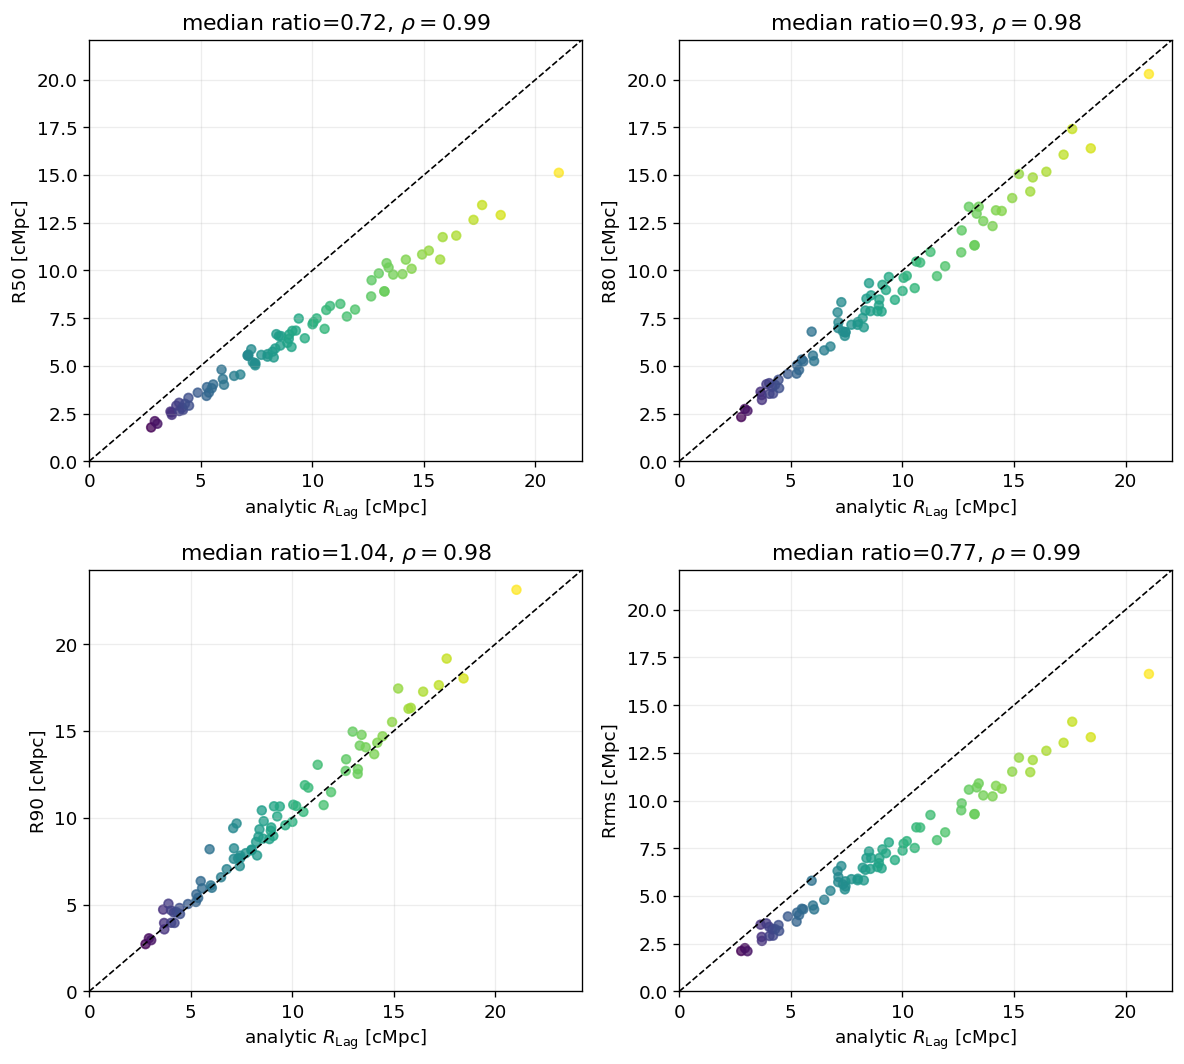

In [9]:
radius_columns = ["R50_cMpc", "R68_cMpc", "R80_cMpc", "R90_cMpc", "Rrms_cMpc"]
ratio_rows = []
for column in radius_columns:
    ratio = summary[column]/summary["R_Lag_analytic_cMpc"]
    q16, q50, q84 = np.percentile(ratio, [16, 50, 84])
    rho, p = spearmanr(summary["R_Lag_analytic_cMpc"], summary[column])
    ratio_rows.append({"Radius": column, "Ratio16": q16, "MedianRatio": q50,
                       "Ratio84": q84, "Spearman_rho": rho, "p_value": p})
analytic_comparison = pd.DataFrame(ratio_rows)
display(analytic_comparison.round(4))

plot_columns = ["R50_cMpc", "R80_cMpc", "R90_cMpc", "Rrms_cMpc"]
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, column in zip(axes.flat, plot_columns):
    ax.scatter(summary["R_Lag_analytic_cMpc"], summary[column],
               c=summary["logM200c_z0"], s=28, alpha=0.75)
    limits = [0, 1.05*max(summary["R_Lag_analytic_cMpc"].max(), summary[column].max())]
    ax.plot(limits, limits, "k--", lw=1)
    row = analytic_comparison[analytic_comparison["Radius"] == column].iloc[0]
    ax.set(xlabel=r"analytic $R_{\rm Lag}$ [cMpc]", ylabel=column.replace("_cMpc", " [cMpc]"),
           xlim=limits, ylim=limits,
           title=rf"median ratio={row['MedianRatio']:.2f}, $\rho={row['Spearman_rho']:.2f}$")
plt.tight_layout()
plt.show()

## 11. Descendant-mass dependence and environmental optimal radius

Mass-dependent $R_{\rm environment,opt}$ values are read from the preceding robustness output when available. Otherwise the globally best halo-count scale is used for every bin and explicitly flagged as a fallback.

,M0_bin,N,MedianLogM0,Ropt,R_Lag_analytic_cMpc,R50_cMpc,R80_cMpc,R90_cMpc,Rrms_cMpc
0,12.5-13.5,20,13.083,5.0,4.189,2.919,3.951,4.625,3.325
1,13.5-14.0,20,13.821,8.0,7.379,5.464,7.002,7.899,5.812
2,14.0-14.5,20,14.154,15.0,9.529,6.898,9.163,10.385,7.414
3,>14.5,20,14.685,20.0,14.322,10.476,13.340,14.870,10.837


Ropt source: mass-bin values from previous robustness analysis


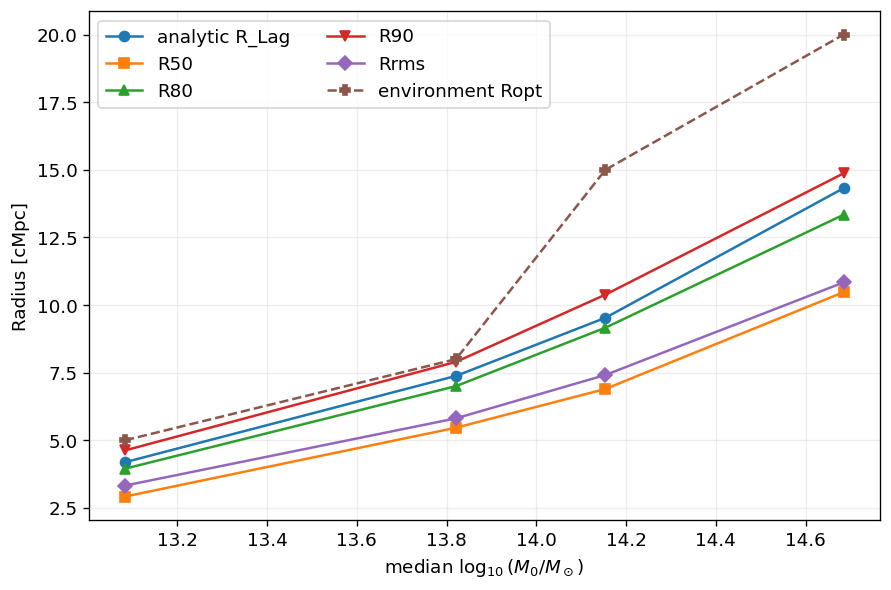

Median |particle radius - Ropt|: {'R50_cMpc': 4.434728367212338, 'R80_cMpc': 2.6334462442687228, 'R90_cMpc': 2.0021445008572707, 'Rrms_cMpc': 3.59757980765115}
Closest particle-defined statistic: R90_cMpc


In [10]:
if lagrangian_scale_path.is_file():
    previous_scale = pd.read_csv(lagrangian_scale_path)
    r_opt_map = dict(zip(previous_scale["M0_bin"].astype(str), previous_scale["R_opt_cMpc"]))
    r_opt_source = "mass-bin values from previous robustness analysis"
elif robustness_summary_path.is_file():
    robust = pd.read_csv(robustness_summary_path)
    best = robust.iloc[np.nanargmax(np.abs(robust["rho_max"]))]
    r_opt_map = {label: float(best["R_opt_cMpc"]) for label in mass_labels}
    r_opt_source = "global fallback from previous robustness analysis"
else:
    r_opt_map = {label: 10.0 for label in mass_labels}
    r_opt_source = "10 cMpc fallback"

summary["R_environment_opt_cMpc"] = summary["M0_bin"].astype(str).map(r_opt_map)
mass_summary_rows = []
for label, group in summary.groupby("M0_bin", observed=True):
    row = {"M0_bin": str(label), "N": len(group), "MedianLogM0": group["logM200c_z0"].median(),
           "Ropt": group["R_environment_opt_cMpc"].median()}
    for column in ["R_Lag_analytic_cMpc", "R50_cMpc", "R80_cMpc", "R90_cMpc", "Rrms_cMpc"]:
        row[column] = group[column].median()
    mass_summary_rows.append(row)
mass_radius_summary = pd.DataFrame(mass_summary_rows)
display(mass_radius_summary.round(3))
print(f"Ropt source: {r_opt_source}")

fig, ax = plt.subplots(figsize=(8.5, 5.5))
styles = {
    "R_Lag_analytic_cMpc": ("o-", "analytic R_Lag"),
    "R50_cMpc": ("s-", "R50"), "R80_cMpc": ("^-", "R80"),
    "R90_cMpc": ("v-", "R90"), "Rrms_cMpc": ("D-", "Rrms"),
    "Ropt": ("P--", "environment Ropt"),
}
for column, (style, label) in styles.items():
    ax.plot(mass_radius_summary["MedianLogM0"], mass_radius_summary[column], style, label=label)
ax.set(xlabel=r"median $\log_{10}(M_0/M_\odot)$", ylabel="Radius [cMpc]")
ax.legend(ncol=2)
plt.show()

particle_radius_names = ["R50_cMpc", "R80_cMpc", "R90_cMpc", "Rrms_cMpc"]
median_abs_difference = {
    column: np.median(np.abs(summary[column]-summary["R_environment_opt_cMpc"]))
    for column in particle_radius_names
}
closest_radius_to_ropt = min(median_abs_difference, key=median_abs_difference.get)
print("Median |particle radius - Ropt|:", median_abs_difference)
print("Closest particle-defined statistic:", closest_radius_to_ropt)

## 12. Proto-halo shape analysis

Axis-ratio and triaxiality distributions are compared by descendant-mass bin. The correlation between $R_{\rm opt}/R_{\rm Lag}$ and $c/a$ tests whether more elongated regions preferentially require apertures larger than the spherical top-hat scale.

,N,median_b_over_a,median_c_over_a,median_T
M0_bin,,,,
12.5-13.5,20,0.801,0.662,0.594
13.5-14.0,20,0.786,0.619,0.648
14.0-14.5,20,0.823,0.671,0.685
>14.5,20,0.842,0.724,0.599


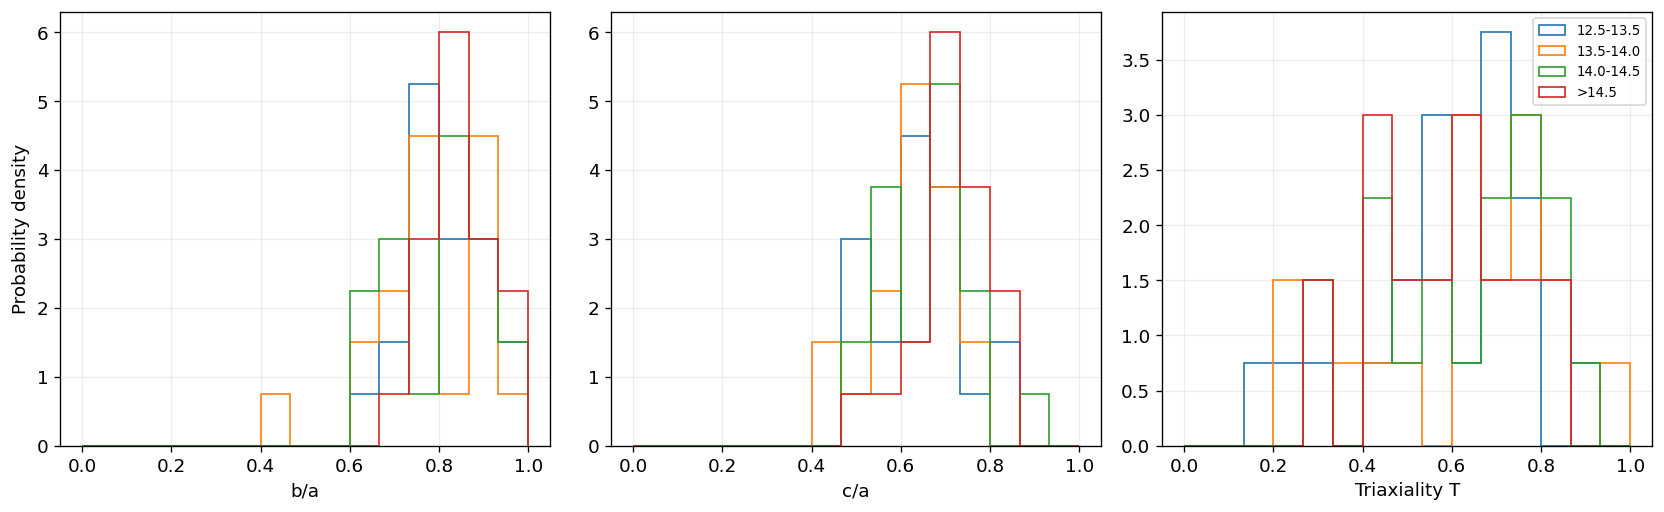

Spearman rho(Ropt/RLag, c/a)=+0.124, p=2.744e-01


In [11]:
shape_summary = summary.groupby("M0_bin", observed=True).agg(
    N=("GroupID_z0", "size"),
    median_b_over_a=("b_over_a", "median"),
    median_c_over_a=("c_over_a", "median"),
    median_T=("Triaxiality", "median"),
)
display(shape_summary.round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
for label, group in summary.groupby("M0_bin", observed=True):
    axes[0].hist(group["b_over_a"], bins=np.linspace(0, 1, 16), histtype="step", density=True, label=str(label))
    axes[1].hist(group["c_over_a"], bins=np.linspace(0, 1, 16), histtype="step", density=True, label=str(label))
    axes[2].hist(group["Triaxiality"], bins=np.linspace(0, 1, 16), histtype="step", density=True, label=str(label))
axes[0].set(xlabel="b/a", ylabel="Probability density")
axes[1].set(xlabel="c/a")
axes[2].set(xlabel="Triaxiality T")
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

summary["Ropt_over_RLag"] = summary["R_environment_opt_cMpc"]/summary["R_Lag_analytic_cMpc"]
shape_valid = summary[["Ropt_over_RLag", "c_over_a"]].notna().all(axis=1)
rho_shape, p_shape = spearmanr(
    summary.loc[shape_valid, "Ropt_over_RLag"], summary.loc[shape_valid, "c_over_a"]
)
print(f"Spearman rho(Ropt/RLag, c/a)={rho_shape:+.3f}, p={p_shape:.3e}")

## 13. Representative proto-halo visualizations

For each mass bin, the halo closest to the bin's median $M_0$ and the most elongated halo (lowest $c/a$) are shown in the $xy$ plane. Coordinates are minimum-image offsets from the circular center. Circles show analytic $R_{\rm Lag}$, particle radii, and the previous environmental optimum; the target $z\simeq8$ FoF center is marked separately.

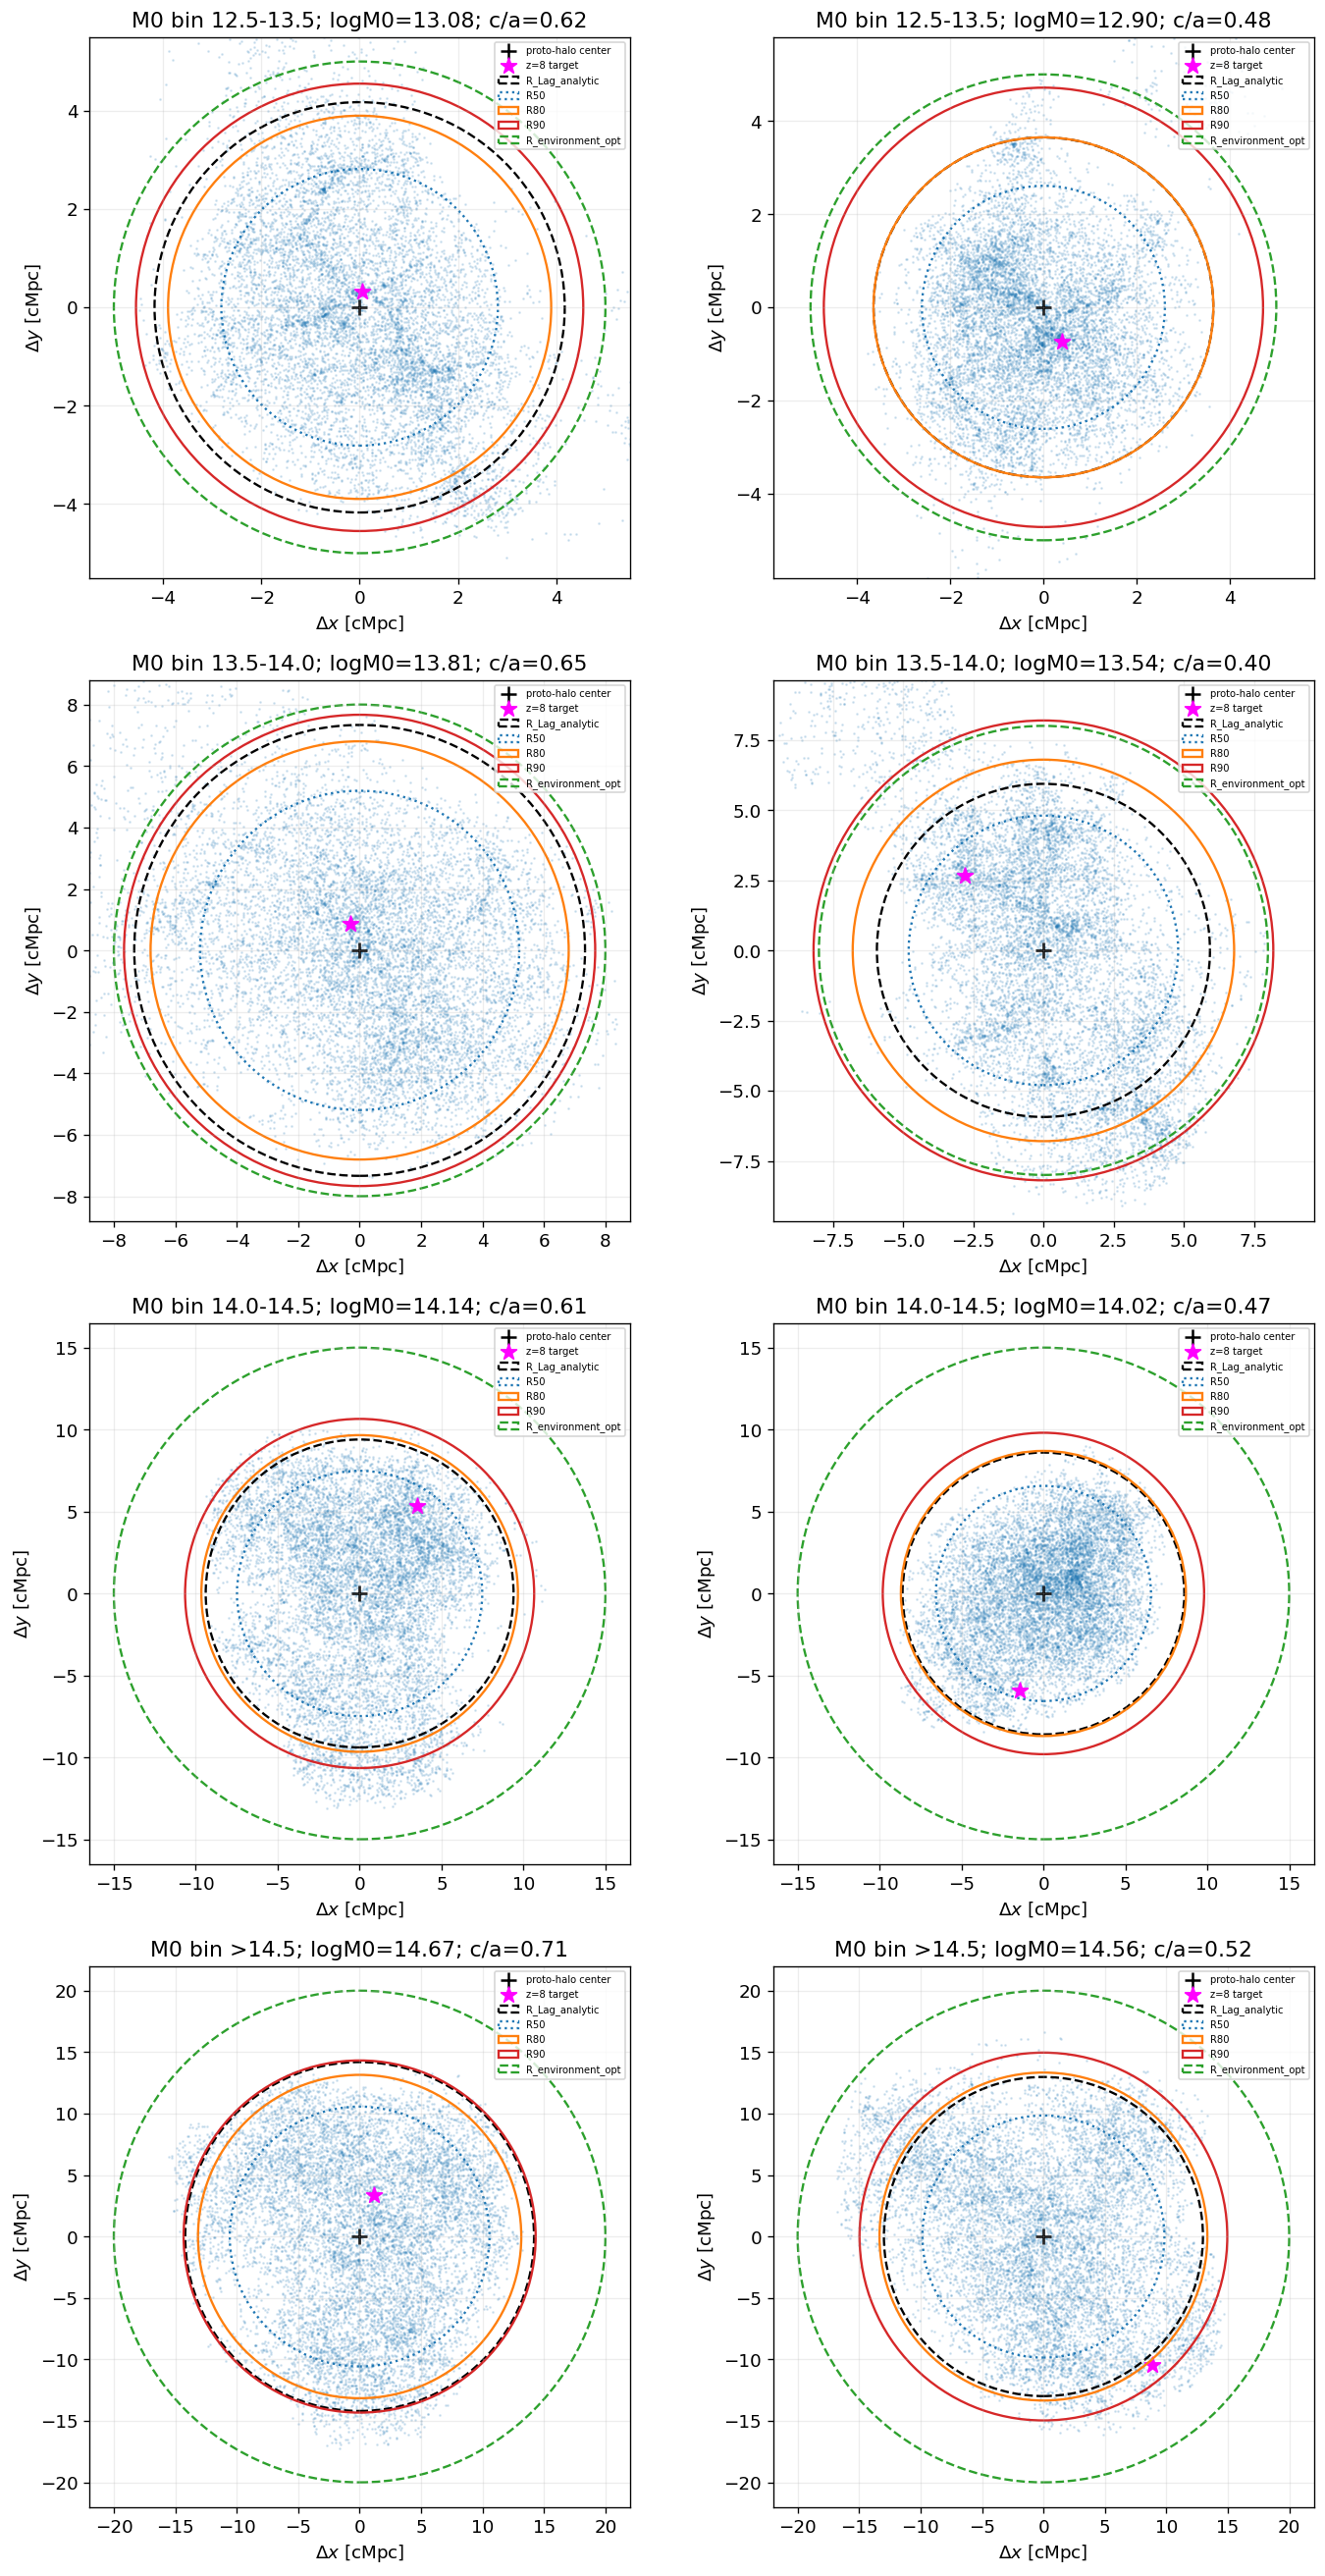

In [12]:
representative_indices = []
for label, group in summary.groupby("M0_bin", observed=True):
    median_idx = (group["logM200c_z0"]-group["logM200c_z0"].median()).abs().idxmin()
    elongated_idx = group["c_over_a"].idxmin()
    if elongated_idx == median_idx and len(group) > 1:
        elongated_idx = group.nsmallest(2, "c_over_a").index[-1]
    representative_indices.extend([median_idx, elongated_idx])
representative_indices = list(dict.fromkeys(representative_indices))

ncols = 2
nrows = int(np.ceil(len(representative_indices)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5.5*nrows))
axes = np.atleast_1d(axes).flat
circle_specs = [
    ("R_Lag_analytic_cMpc", "k", "--"), ("R50_cMpc", "tab:blue", ":"),
    ("R80_cMpc", "tab:orange", "-"), ("R90_cMpc", "tab:red", "-"),
    ("R_environment_opt_cMpc", "tab:green", "--"),
]
for ax, idx in zip(axes, representative_indices):
    row = summary.loc[idx]
    gid = int(row["GroupID_z0"])
    coords = proto_coords[gid]
    center = np.array([row["CenterX_cMpc"], row["CenterY_cMpc"], row["CenterZ_cMpc"]])
    offsets = periodic_delta(coords, center, box_size_cMpc)
    if len(offsets) > max_plot_particles:
        keep = np.random.default_rng(random_seed+gid).choice(len(offsets), max_plot_particles, replace=False)
        plot_offsets = offsets[keep]
    else:
        plot_offsets = offsets
    ax.scatter(plot_offsets[:, 0], plot_offsets[:, 1], s=0.35, alpha=0.2, rasterized=True)
    target_offset = periodic_delta(
        np.array([row["TargetX_cMpc"], row["TargetY_cMpc"], row["TargetZ_cMpc"]]), center, box_size_cMpc
    )
    ax.scatter(0, 0, marker="+", s=90, color="k", label="proto-halo center")
    ax.scatter(target_offset[0], target_offset[1], marker="*", s=100, color="magenta", label="z=8 target")
    for column, color, linestyle in circle_specs:
        ax.add_patch(Circle((0, 0), row[column], fill=False, color=color, ls=linestyle,
                            lw=1.4, label=column.replace("_cMpc", "")))
    limit = 1.1*max(row["R90_cMpc"], row["R_environment_opt_cMpc"],
                    np.percentile(np.sqrt(np.sum(offsets[:, :2]**2, axis=1)), 95))
    ax.set(xlim=(-limit, limit), ylim=(-limit, limit), aspect="equal",
           xlabel=r"$\Delta x$ [cMpc]", ylabel=r"$\Delta y$ [cMpc]",
           title=f"M0 bin {row['M0_bin']}; logM0={row['logM200c_z0']:.2f}; c/a={row['c_over_a']:.2f}")
    ax.legend(fontsize=6, loc="upper right")
for ax in axes:
    if not ax.has_data():
        ax.axis("off")
plt.tight_layout()
plt.show()

## 14. Direct comparison with the environment

`Nhalo_R10` is compared with proto-halo sizes and $c/a$ globally and within each descendant-mass bin. Within-bin correlations help distinguish simple mass prediction from sensitivity to proto-halo geometry.

In [13]:
def safe_spearman(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    valid = np.isfinite(x) & np.isfinite(y)
    if valid.sum() < 5 or np.unique(x[valid]).size < 2 or np.unique(y[valid]).size < 2:
        return np.nan, np.nan, int(valid.sum())
    rho, p = spearmanr(x[valid], y[valid])
    return float(rho), float(p), int(valid.sum())


environment_column = "Nhalo_R10" if "Nhalo_R10" in summary.columns else None
environment_correlation_rows = []
if environment_column is not None:
    geometry_columns = ["R50_cMpc", "R80_cMpc", "R90_cMpc", "Rrms_cMpc", "c_over_a"]
    for geometry in geometry_columns:
        rho, p, n = safe_spearman(summary[environment_column], summary[geometry])
        environment_correlation_rows.append({"M0_bin": "all", "Geometry": geometry,
                                             "rho": rho, "p_value": p, "N": n})
    for label, group in summary.groupby("M0_bin", observed=True):
        for geometry in geometry_columns:
            rho, p, n = safe_spearman(group[environment_column], group[geometry])
            environment_correlation_rows.append({"M0_bin": str(label), "Geometry": geometry,
                                                 "rho": rho, "p_value": p, "N": n})
    environment_geometry_correlations = pd.DataFrame(environment_correlation_rows)
    display(environment_geometry_correlations.round(4))
else:
    environment_geometry_correlations = pd.DataFrame()
    print("Nhalo_R10 is unavailable; run the environment notebook for this comparison.")

,M0_bin,Geometry,rho,p_value,N
0,all,R50_cMpc,0.7571,0.0000,80
1,all,R80_cMpc,0.7543,0.0000,80
2,all,R90_cMpc,0.7475,0.0000,80
3,all,Rrms_cMpc,0.7594,0.0000,80
4,all,c_over_a,0.3052,0.0059,80
5,12.5-13.5,R50_cMpc,0.2211,0.3488,20
6,12.5-13.5,R80_cMpc,0.2354,0.3177,20
7,12.5-13.5,R90_cMpc,0.2136,0.3658,20
8,12.5-13.5,Rrms_cMpc,0.2738,0.2428,20
9,12.5-13.5,c_over_a,-0.4385,0.0531,20


## 15. Fraction of eventual descendant particles inside target-centered apertures

`fprog_R*` is the fraction of the matched, unbiased DM subsample lying within a sphere centered on the selected $z\simeq8$ target FoF position. It estimates the full descendant-particle fraction; sampling uncertainty is small for $10^5$ particles but the statistic is still a Monte Carlo estimate for large halos.

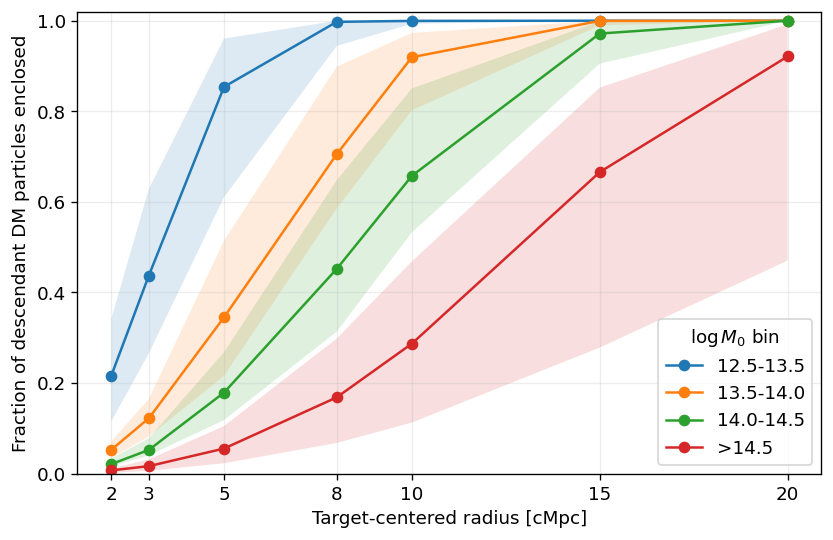

,M0_bin,R_cMpc,fprog16,fprog50,fprog84
0,12.5-13.5,2.0,0.115,0.216,0.342
1,12.5-13.5,3.0,0.266,0.438,0.629
2,12.5-13.5,5.0,0.610,0.854,0.961
3,12.5-13.5,8.0,0.944,0.998,1.000
4,12.5-13.5,10.0,0.993,1.000,1.000
5,12.5-13.5,15.0,1.000,1.000,1.000
6,12.5-13.5,20.0,1.000,1.000,1.000
7,13.5-14.0,2.0,0.035,0.053,0.071
8,13.5-14.0,3.0,0.082,0.122,0.165
9,13.5-14.0,5.0,0.216,0.345,0.514


fprog at assigned Ropt, median and 16-84%: [0.602528 0.89805  0.99052 ]


In [14]:
fprog_columns = [f"fprog_R{radius:g}" for radius in fprog_radii_cMpc]
fig, ax = plt.subplots(figsize=(8, 5))
fprog_summary_rows = []
for label, group in summary.groupby("M0_bin", observed=True):
    values = group[fprog_columns].to_numpy()
    med = np.median(values, axis=0)
    lo = np.percentile(values, 16, axis=0)
    hi = np.percentile(values, 84, axis=0)
    ax.plot(fprog_radii_cMpc, med, "o-", label=str(label))
    ax.fill_between(fprog_radii_cMpc, lo, hi, alpha=0.15)
    for radius, m, p16, p84 in zip(fprog_radii_cMpc, med, lo, hi):
        fprog_summary_rows.append({"M0_bin": str(label), "R_cMpc": radius,
                                   "fprog16": p16, "fprog50": m, "fprog84": p84})
ax.set(xlabel="Target-centered radius [cMpc]", ylabel="Fraction of descendant DM particles enclosed",
       xticks=fprog_radii_cMpc, ylim=(0, 1.02))
ax.legend(title=r"$\log M_0$ bin")
plt.show()
fprog_summary = pd.DataFrame(fprog_summary_rows)
display(fprog_summary.round(3))

summary["fprog_at_Ropt"] = [
    np.interp(row.R_environment_opt_cMpc, fprog_radii_cMpc,
              [getattr(row, f"fprog_R{radius:g}") for radius in fprog_radii_cMpc])
    for row in summary.itertuples(index=False)
]
print("fprog at assigned Ropt, median and 16-84%:",
      np.percentile(summary["fprog_at_Ropt"], [16, 50, 84]))

## 16. Save the halo-level summary table

In [15]:
output_columns = [
    "GroupID_z8", "SubhaloID_z8", "GroupID_z0", "SubhaloID_z0",
    "logM200c_z8", "logM200c_z0", "M0_bin", "ParticleMembership", "N_DM_total", "N_DM_sampled",
    "N_DM_matched", "DM_match_fraction", "R_Lag_analytic_cMpc",
    "R50_cMpc", "R68_cMpc", "R80_cMpc", "R90_cMpc", "Rrms_cMpc",
    "b_over_a", "c_over_a", "Triaxiality", "R_environment_opt_cMpc",
    "fprog_at_Ropt",
]
for optional in ["Nhalo_R10", "Ngal_R10"]:
    if optional in summary.columns:
        output_columns.append(optional)
output_columns += fprog_columns

output_table = summary[output_columns].copy()
output_path = cache_dir/"tng300_protohalo_particle_summary.csv"
output_table.to_csv(output_path, index=False)
analytic_comparison.to_csv(cache_dir/"analytic_vs_particle_radius_summary.csv", index=False)
mass_radius_summary.to_csv(cache_dir/"mass_bin_radius_summary.csv", index=False)
fprog_summary.to_csv(cache_dir/"fprog_mass_bin_summary.csv", index=False)
print(f"Saved halo-level table: {output_path}")
display(output_table.head())

Saved halo-level table: /home/tnguser/tng-work/protohalo_particle_cache/tng300_protohalo_particle_summary.csv


,GroupID_z8,SubhaloID_z8,GroupID_z0,SubhaloID_z0,logM200c_z8,logM200c_z0,M0_bin,ParticleMembership,N_DM_total,N_DM_sampled,...,fprog_at_Ropt,Nhalo_R10,Ngal_R10,fprog_R2,fprog_R3,fprog_R5,fprog_R8,fprog_R10,fprog_R15,fprog_R20
0,5891,22473,8961,1385849,10.841385,12.548933,12.5-13.5,R200c,57136,10000,...,0.9807,124,2,0.4993,0.8678,0.9807,0.9980,0.9996,1.0,1.0
1,5392,21027,9529,1405515,10.844920,12.624199,12.5-13.5,R200c,66945,10000,...,0.9825,117,1,0.4418,0.7263,0.9825,1.0000,1.0000,1.0,1.0
2,4974,19746,9728,1412398,10.865236,12.673652,12.5-13.5,R200c,76822,10000,...,1.0000,82,0,0.5125,0.8835,1.0000,1.0000,1.0000,1.0,1.0
3,1230,6869,3712,1100000,10.832026,12.902604,12.5-13.5,R200c,128616,10000,...,0.8786,173,1,0.3440,0.6312,0.8786,0.9549,0.9757,1.0,1.0
4,4479,18191,5773,1242874,10.885653,12.919412,12.5-13.5,R200c,134745,10000,...,0.9351,159,0,0.2266,0.4774,0.9351,0.9977,0.9987,1.0,1.0


## Automatically generated scientific summary

In [16]:
closest_to_analytic = analytic_comparison.iloc[
    np.argmin(np.abs(analytic_comparison["MedianRatio"]-1.0))
]
fprog16, fprog50, fprog84 = np.percentile(summary["fprog_at_Ropt"], [16, 50, 84])
median_ca = summary["c_over_a"].median()
median_ba = summary["b_over_a"].median()
median_t = summary["Triaxiality"].median()
center_difference_84 = np.percentile(summary["CenterMethodDifference_cMpc"], 84)

size_mass_rhos = {
    column: spearmanr(summary["logM200c_z0"], summary[column])[0]
    for column in ["R50_cMpc", "R80_cMpc", "R90_cMpc", "Rrms_cMpc"]
}

hypothesis_supported = (
    0.5 <= np.median(summary["R_environment_opt_cMpc"]/summary[closest_radius_to_ropt]) <= 2.0
    and fprog50 >= 0.5
)

display(Markdown(fr"""
### Scientific summary

1. The analytic top-hat radius is closest to **{closest_to_analytic['Radius']}**, whose particle-to-analytic ratio is
   {closest_to_analytic['MedianRatio']:.2f} (16–84%: {closest_to_analytic['Ratio16']:.2f}–{closest_to_analytic['Ratio84']:.2f})
   and whose rank correlation is $\rho={closest_to_analytic['Spearman_rho']:.3f}$.
2. The previous environmental optimum is closest to **{closest_radius_to_ropt}** by the median absolute radius difference.
3. Proto-halo sizes grow with descendant mass: the rank coefficients are
   {', '.join(f'{name.replace("_cMpc", "")}: {rho:+.2f}' for name, rho in size_mass_rhos.items())}.
4. The regions are substantially non-spherical when the median axis ratios depart from unity:
   median $b/a={median_ba:.2f}$, $c/a={median_ca:.2f}$, and $T={median_t:.2f}$.
5. The correlation $\rho(R_{{\rm opt}}/R_{{\rm Lag}},c/a)={rho_shape:+.3f}$ tests the geometry explanation directly.
   A significant negative value would support larger relative apertures for more elongated patches; absence of such a trend
   would argue against shape as the sole explanation.
6. At the assigned $R_{{\rm opt}}$, the target-centered aperture contains a median descendant-DM fraction of
   **{fprog50:.1%}** (16–84%: {fprog16:.1%}–{fprog84:.1%}).
7. Circular-mean and reference-unwrapped centers agree to within {center_difference_84:.3f} cMpc for 84% of the sample.
8. Under the deliberately simple criteria “$R_{{\rm opt}}$ within a factor two of its closest particle radius” and
   “median enclosed descendant fraction $\geq50\%$,” the hypothesis that environmental scale traces the physical
   proto-halo/Lagrangian region is **{'supported' if hypothesis_supported else 'not yet supported'}** by this subsample.

This is a particle-subsampled, unique-descendant pilot analysis. Convergence should be checked by increasing both
`n_per_mass_bin` and `max_dm_particles_per_halo`, and by verifying that the conclusions are stable to center and shape estimators.
"""))


### Scientific summary

1. The analytic top-hat radius is closest to **R90_cMpc**, whose particle-to-analytic ratio is
   1.04 (16–84%: 0.98–1.14)
   and whose rank correlation is $\rho=0.979$.
2. The previous environmental optimum is closest to **R90_cMpc** by the median absolute radius difference.
3. Proto-halo sizes grow with descendant mass: the rank coefficients are
   R50: +0.99, R80: +0.98, R90: +0.98, Rrms: +0.99.
4. The regions are substantially non-spherical when the median axis ratios depart from unity:
   median $b/a=0.82$, $c/a=0.67$, and $T=0.63$.
5. The correlation $\rho(R_{\rm opt}/R_{\rm Lag},c/a)=+0.124$ tests the geometry explanation directly.
   A significant negative value would support larger relative apertures for more elongated patches; absence of such a trend
   would argue against shape as the sole explanation.
6. At the assigned $R_{\rm opt}$, the target-centered aperture contains a median descendant-DM fraction of
   **89.8%** (16–84%: 60.3%–99.1%).
7. Circular-mean and reference-unwrapped centers agree to within 0.006 cMpc for 84% of the sample.
8. Under the deliberately simple criteria “$R_{\rm opt}$ within a factor two of its closest particle radius” and
   “median enclosed descendant fraction $\geq50\%$,” the hypothesis that environmental scale traces the physical
   proto-halo/Lagrangian region is **supported** by this subsample.

This is a particle-subsampled, unique-descendant pilot analysis. Convergence should be checked by increasing both
`n_per_mass_bin` and `max_dm_particles_per_halo`, and by verifying that the conclusions are stable to center and shape estimators.
